In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [ ]:
#Question 6
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models
( X_train , y_train ) , ( X_test , y_test ) = fashion_mnist.load_data()
#print(X_train.shape, y_train.shape)
#print(X_test.shape, y_test.shape)

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0
X_train = X_train[..., None]
X_test = X_test[..., None]
#print("train shape:", X_train.shape)

model = models.Sequential([layers.Input(shape=(28, 28, 1)),
                           layers.Conv2D(32, (3,3), padding="same", activation="relu"),
                           layers.MaxPooling2D((2,2)),
                           layers.Flatten(),
                           layers.Dense(10, activation="softmax")])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history = model.fit(X_train, y_train, validation_split=0.1, epochs=15, batch_size=64)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("Test accuracy:", test_acc)

'''
'''

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 815us/step
<class 'numpy.ndarray'>
<class 'numpy.int64'>


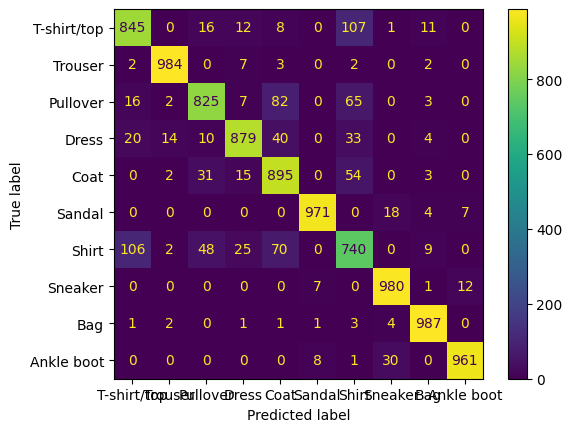

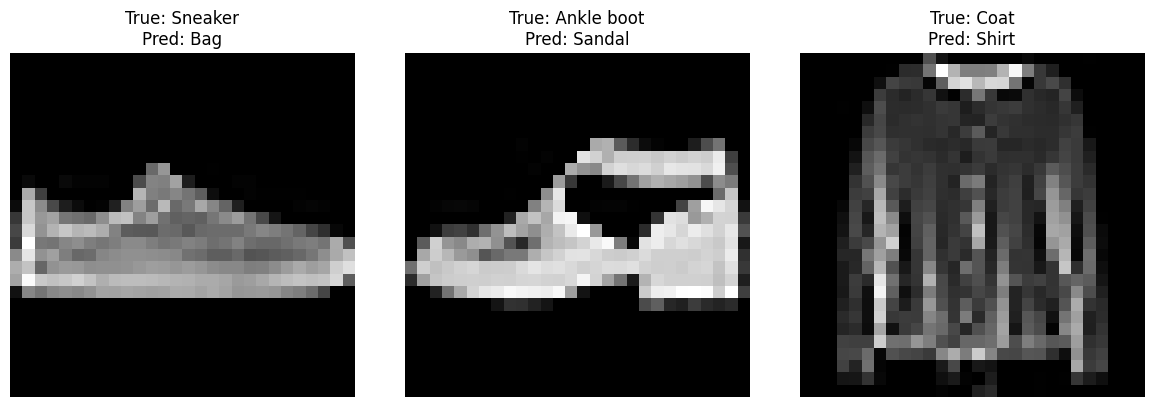

In [ ]:
#Question 7 
fashionMNIST_labels = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat','Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

predictions = model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)

cm = confusion_matrix(y_test.flatten(), predicted_labels.flatten())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels= fashionMNIST_labels)
disp.plot()

misclassified = np.where(predicted_labels != y_test)[0]
print(type(misclassified))        # Should be <class 'numpy.ndarray'>
print(type(misclassified[0]))     # Should be <class 'numpy.int64'>

plt.figure(figsize=(12, 4))

for i, id in enumerate(misclassified[:3]):
    plt.subplot(1, 3, i + 1)
  
    plt.imshow(X_test[id].reshape(28, 28), cmap='gray')
    plt.title(f"True: {fashionMNIST_labels[y_test[id]]}\nPred: {fashionMNIST_labels[predicted_labels[id]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()


'''
  - The confusion matrix shows clothing with similar shapes get misclassified like t-shirts as shirts and vice-versa.

  - One way to improve performance would be to add more layers, but this can lead to worse overfitting but different layerscan be added and taken away to determine the optimal mix.
'''